In [29]:
import numpy as np
import matplotlib.pyplot as plt

[[-2. -2.]
 [ 0.  0.]]
[[-2. -2.]
 [ 0.  0.]]
[[-2. -2.]
 [ 0.  0.]]
[[-2. -2.]
 [ 0.  0.]]


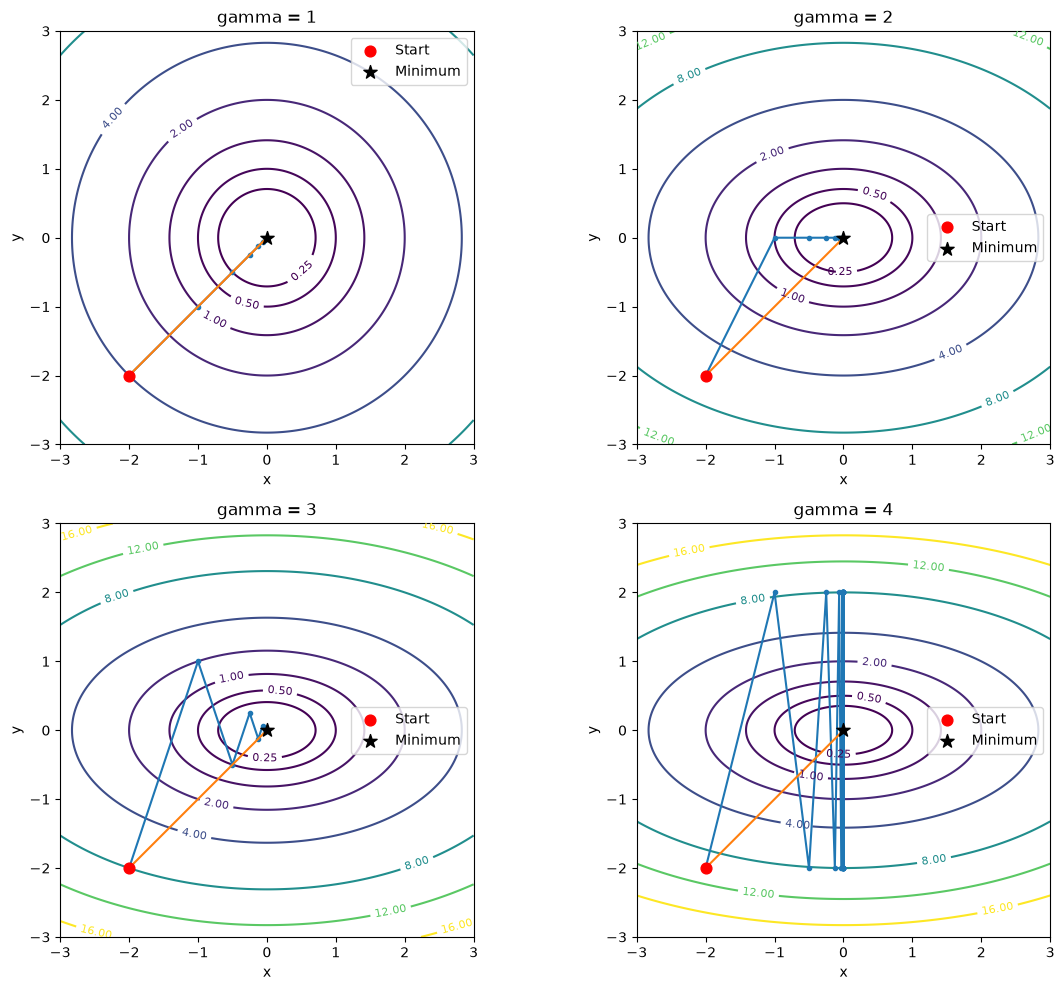

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 300)
y = np.linspace(-3, 3, 300)
X, Y = np.meshgrid(x, y)

gammas = [1, 2, 3, 4]
num_iterations = 25
learning_rate = 0.5

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for gamma, ax in zip(gammas, axes):
    Z = 0.5 * (X**2 + gamma * Y**2)

    contours = ax.contour(
        X, Y, Z,
        levels=[0.25, 0.5, 1, 2, 4, 8, 12, 16],
        cmap="viridis"
    )
    ax.clabel(contours, inline=True, fontsize=8)

    # Initial parameters
    grad_point = np.array([-2.0, -2.0])
    grad_history = [grad_point.copy()]
    for _ in range(num_iterations):
        gradient = np.array([
            grad_point[0],
            gamma * grad_point[1]
        ])
        grad_point = grad_point - learning_rate * gradient
        grad_history.append(grad_point.copy())
    grad_history = np.array(grad_history)

    grad_point = np.array([-2.0, -2.0])
    
    # Newton method
    hessian_point =  np.array([-2.0, -2.0])
    hessian_history = [hessian_point.copy()]
    gradient = np.array([
                grad_point[0],
                gamma * grad_point[1]
            ])
    hessian_inv = 1 / gamma * np.array([[gamma,0],[0,1]])
    hessian_point = hessian_point - (hessian_inv @ gradient)
    hessian_history.append(hessian_point.copy())
    hessian_history = np.array(hessian_history)
    print(hessian_history)

    ax.plot(
        grad_history[:, 0],
        grad_history[:, 1],
        "-o",
        markersize=3,
        linewidth=1.5
    )

    ax.plot(
            hessian_history[:, 0],
            hessian_history[:, 1],
            "-x",
            markersize=3,
            linewidth=1.5
        )    

    ax.scatter(*grad_history[0], color="red",
               s=60, label="Start", zorder=5)

    ax.scatter(0, 0, color="black",
               marker="*", s=100,
               label="Minimum", zorder=5)

    ax.set_title(f"gamma = {gamma}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.legend()

plt.tight_layout()
plt.show()


[[-2. -2.]
 [ 0.  0.]]
[[-2. -2.]
 [ 0.  0.]]
[[-2. -2.]
 [ 0.  0.]]
[[-2. -2.]
 [ 0.  0.]]


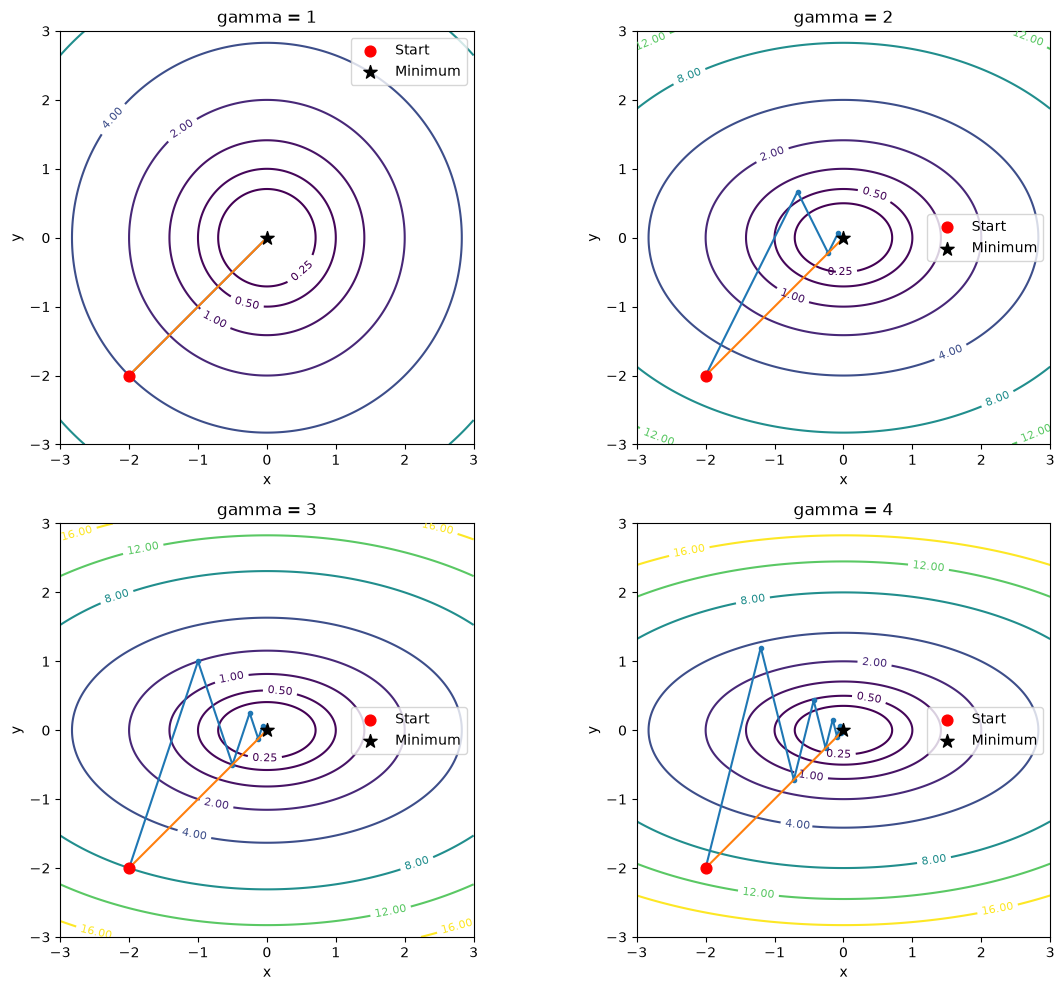

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 300)
y = np.linspace(-3, 3, 300)
X, Y = np.meshgrid(x, y)

gammas = [1, 2, 3, 4]
num_iterations = 25

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for gamma, ax in zip(gammas, axes):
    learning_rate = 2 / (1 + gamma)
    Z = 0.5 * (X**2 + gamma * Y**2)

    contours = ax.contour(
        X, Y, Z,
        levels=[0.25, 0.5, 1, 2, 4, 8, 12, 16],
        cmap="viridis"
    )
    ax.clabel(contours, inline=True, fontsize=8)

    # Initial parameters
    grad_point = np.array([-2.0, -2.0])
    grad_history = [grad_point.copy()]
    for _ in range(num_iterations):
        gradient = np.array([
            grad_point[0],
            gamma * grad_point[1]
        ])
        grad_point = grad_point - learning_rate * gradient
        grad_history.append(grad_point.copy())
    grad_history = np.array(grad_history)

    grad_point = np.array([-2.0, -2.0])
    
    # Newton method
    hessian_point =  np.array([-2.0, -2.0])
    hessian_history = [hessian_point.copy()]
    gradient = np.array([
                grad_point[0],
                gamma * grad_point[1]
            ])
    hessian_inv = 1 / gamma * np.array([[gamma,0],[0,1]])
    hessian_point = hessian_point - (hessian_inv @ gradient)
    hessian_history.append(hessian_point.copy())
    hessian_history = np.array(hessian_history)
    print(hessian_history)

    ax.plot(
        grad_history[:, 0],
        grad_history[:, 1],
        "-o",
        markersize=3,
        linewidth=1.5
    )

    ax.plot(
            hessian_history[:, 0],
            hessian_history[:, 1],
            "-x",
            markersize=3,
            linewidth=1.5
        )    

    ax.scatter(*grad_history[0], color="red",
               s=60, label="Start", zorder=5)

    ax.scatter(0, 0, color="black",
               marker="*", s=100,
               label="Minimum", zorder=5)

    ax.set_title(f"gamma = {gamma}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.legend()

plt.tight_layout()
plt.show()
